<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Cars_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('all_car_data.csv')
df.head(11)

,Brand,Car Name,Price,Rating,Safety,Mileage,Power (BHP)
0,Maruti Suzuki,Maruti Brezza,Rs. 8.69 Lakh,4.5/5,NaN,17-25 kmpl,87-102 bhp
1,Maruti Suzuki,Maruti Fronx,Rs. 7.54 Lakh,4.6/5,NaN,20-28 kmpl,76-99 bhp
2,Maruti Suzuki,Maruti Swift,Rs. 6.49 Lakh,4.6/5,NaN,24-32 kmpl,69-80 bhp
3,Maruti Suzuki,Maruti Dzire,Rs. 6.84 Lakh,4.7/5,5 Star Safety,24-33 kmpl,69-80 bhp
4,Maruti Suzuki,Maruti Baleno,Rs. 6.70 Lakh,4.5/5,4 Star Safety,22-30 kmpl,76-88 bhp
5,Maruti Suzuki,Maruti Grand Vitara,Rs. 11.42 Lakh,4.5/5,NaN,19-27 kmpl,87-102 bhp
6,Maruti Suzuki,Maruti Wagon R,Rs. 5.79 Lakh,4.5/5,1 Star Safety,23-34 kmpl,56-90 bhp
7,Maruti Suzuki,Maruti Alto K10,Rs. 4.23 Lakh,4.6/5,2 Star Safety,24-33 kmpl,56-68 bhp
8,Maruti Suzuki,Maruti Ertiga,Rs. 8.97 Lakh,4.6/5,3 Star Safety,20-26 kmpl,87-102 bhp
9,Maruti Suzuki,Maruti XL6,Rs. 11.83 Lakh,4.4/5,3 Star Safety,20-26 kmpl,87-102 bhp


In [3]:
df.tail(11)

,Brand,Car Name,Price,Rating,Safety,Mileage,Power (BHP)
237,Aston Martin,Aston Martin DB11,Rs. 3.29 Crore,4.5/5,NaN,8 kmpl,503-600 bhp
238,Aston Martin,Aston Martin Vantage,Rs. 3.99 Crore,5/5,NaN,NaN,656 bhp
239,Aston Martin,Aston Martin DBX,Rs. 4.63 Crore,4.7/5,NaN,10 kmpl,542-697 bhp
240,Aston Martin,Aston Martin DB12,Rs. 4.59 Crore,4.6/5,NaN,NaN,670 bhp
241,Bentley,Bentley Bentayga,Rs. 4.10 Crore,4.9/5,NaN,7 kmpl,542 bhp
242,McLaren,McLaren 750S,Rs. 5.91 Crore,4.8/5,NaN,NaN,740 bhp
243,McLaren,McLaren 720S,Rs. 4.65 Crore,4.8/5,NaN,8 kmpl,711 bhp
244,McLaren,McLaren GT,Rs. 3.72 Crore,4.5/5,NaN,7 kmpl,612 bhp
245,Lotus,Lotus Eletre,Rs. 2.55 Crore,4.5/5,NaN,NaN,NaN
246,Lotus,Lotus Emira,Rs. 3.22 Crore,5/5,NaN,NaN,360 bhp


In [4]:
df.shape

(248, 7)

In [8]:
df.columns

Index(['Brand', 'Car Name', 'Price', 'Rating', 'Safety', 'Mileage',
       'Power (BHP)'],
      dtype='object')

In [6]:
df.dtypes

,0
Brand,object
Car Name,object
Price,object
Rating,object
Safety,object
Mileage,object
Power (BHP),object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Brand        248 non-null    object
 1   Car Name     248 non-null    object
 2   Price        248 non-null    object
 3   Rating       242 non-null    object
 4   Safety       115 non-null    object
 5   Mileage      128 non-null    object
 6   Power (BHP)  199 non-null    object
dtypes: object(7)
memory usage: 13.7+ KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

,0
Brand,0
Car Name,0
Price,0
Rating,6
Safety,133
Mileage,120
Power (BHP),49


# Handling Missing Data

In [14]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# For numerical columns, we might impute with the mean or median
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Brand          0
Car Name       0
Price          0
Rating         0
Safety         0
Mileage        0
Power (BHP)    0
dtype: int64


# Handling Outliers

In [17]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)].copy()

print('Before removing outleirs:', len(df))
print('After removing outliers:', len(df_outliers))

Before removing outleirs: 248
After removing outliers: 0


# Univariate Analysis

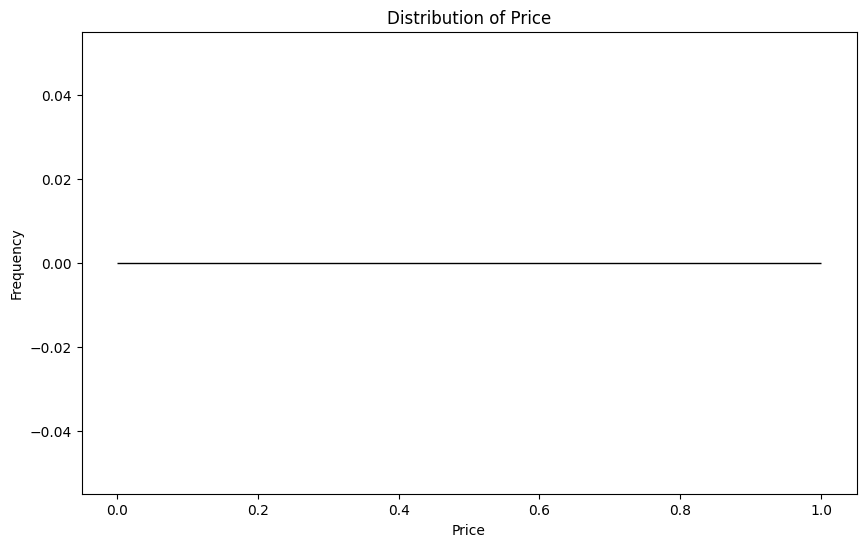

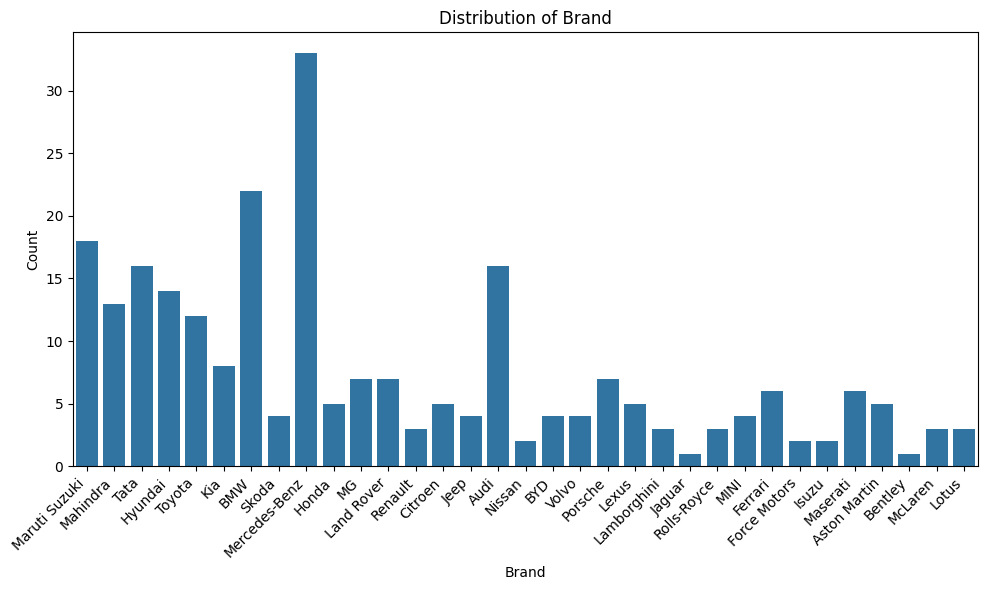

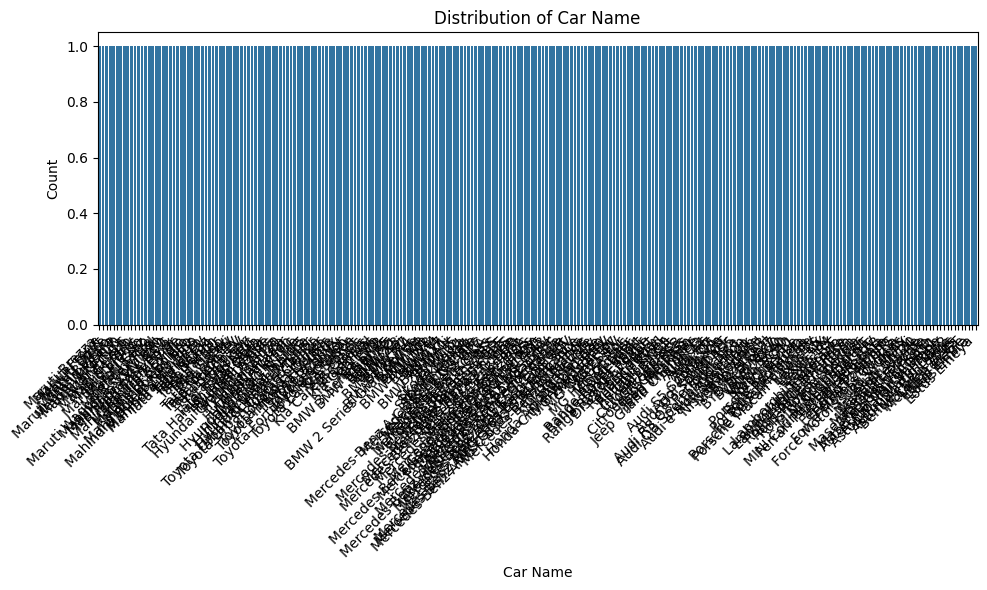

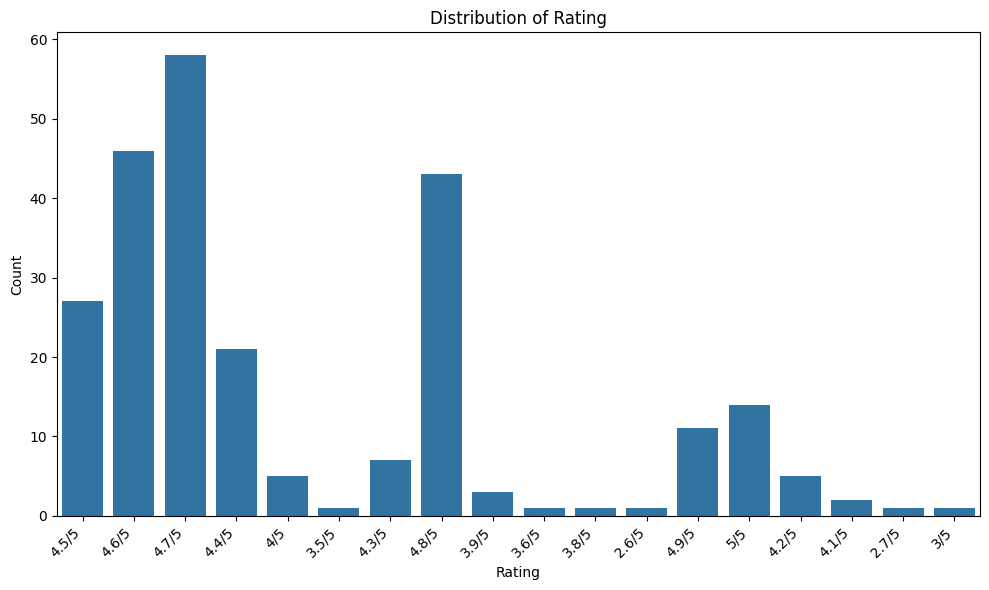

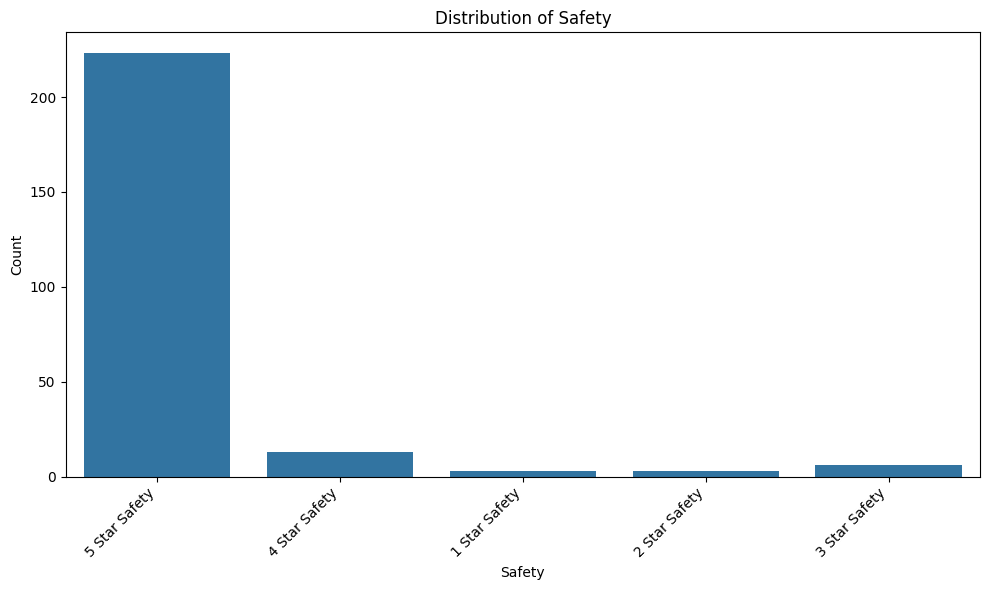

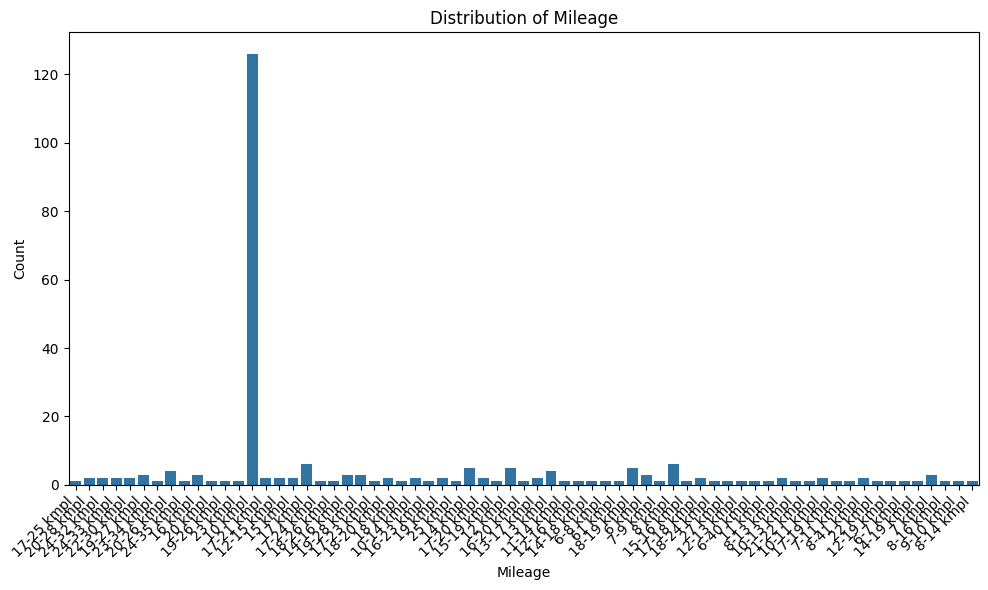

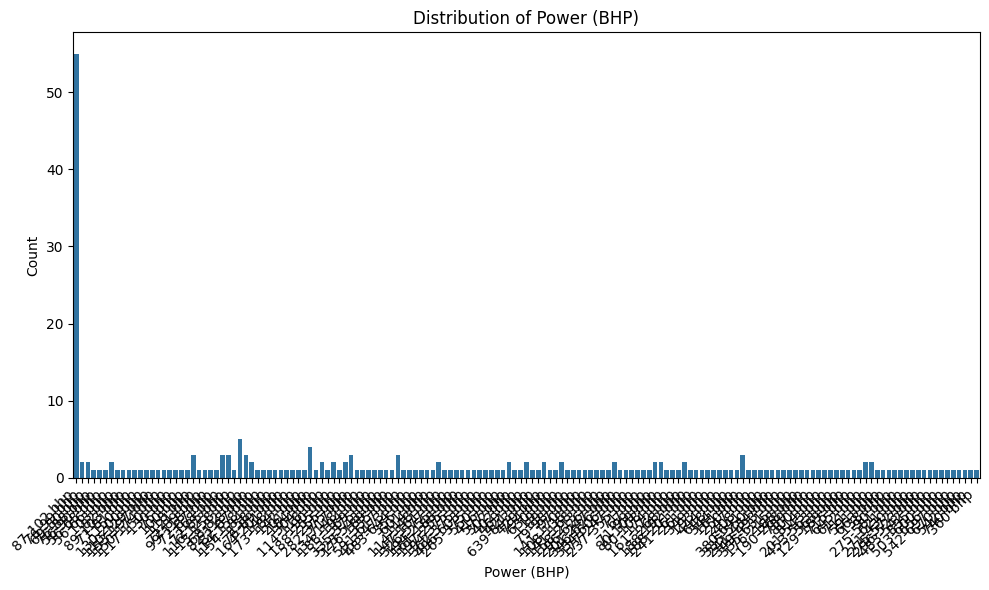

Value counts for Brand:
Brand
Mercedes-Benz    33
BMW              22
Maruti Suzuki    18
Tata             16
Audi             16
Hyundai          14
Mahindra         13
Toyota           12
Kia               8
Land Rover        7
MG                7
Porsche           7
Ferrari           6
Maserati          6
Lexus             5
Citroen           5
Honda             5
Aston Martin      5
MINI              4
Jeep              4
Skoda             4
Volvo             4
BYD               4
Lotus             3
Renault           3
Lamborghini       3
Rolls-Royce       3
McLaren           3
Nissan            2
Isuzu             2
Force Motors      2
Jaguar            1
Bentley           1
Name: count, dtype: int64

Value counts for Car Name:
Car Name
Maruti Brezza    1
Maruti Fronx     1
Maruti Swift     1
Maruti Dzire     1
Maruti Baleno    1
                ..
McLaren 720S     1
McLaren GT       1
Lotus Eletre     1
Lotus Emira      1
Lotus Emeya      1
Name: count, Length: 248, dtype: int64

In [18]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Thank you